# Varentropy of GIG and Joint GH — Formula vs Monte Carlo

**Varentropy** is the variance of the information content (surprisal) $-\log p(X)$:

$$
V_H(X) = \operatorname{Var}\!\left[-\log p(X)\right].
$$

This notebook is a *numerical audit* of two closed-form varentropy formulas for the
distributions in `normix`. We do **not** implement any new API here — we only check
that the formulas are correct by comparing them against a large-sample Monte Carlo
estimate of $\operatorname{Var}[-\log p]$.

The formulas being tested come from the exponential-family structure of these
distributions. For an exponential family with base measure $h(x)=1$,

$$
p(x\mid\theta) = \exp\{\theta^\top t(x) - \psi(\theta)\},
\qquad
V_H(\theta) = \theta^\top \nabla^2\psi(\theta)\,\theta
= \theta^\top I(\theta)\,\theta,
$$

because $-\log p(X) - H = -\theta^\top(t(X)-\eta)$ lies exactly in the score span.
The GIG is exactly such a family (its base measure is $\mathbf 1_{y>0}$, i.e. $\log h\equiv 0$
on the support), so both formulas below are ultimately Fisher quadratic forms
$\theta^\top I\theta$ re-expressed through the Bessel function $K_p$.

**What we check.**

1. **GIG:** $V_H\{\mathrm{GIG}(p,a,b)\} = (L^2 - L)\log K_p(t)$, $\;t=\sqrt{ab}$.
2. **Joint GH** $\big(X\mid Y\sim\mathcal N_d(\mu+\gamma Y,\,\Sigma Y),\ Y\sim\mathrm{GIG}(p,a,b)\big)$:
   $V_H(X,Y) = \tfrac d2 + (L_d^2 - L_d)\log K_p(t)$.

For each we compute the formula three independent ways (an autodiff Bessel operator,
a scipy finite-difference Bessel operator, and `normix`'s own Fisher information) and
compare all of them to Monte Carlo.

In [1]:
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.special import kve

jax.config.update("jax_enable_x64", True)

from normix import GIG
from normix.utils.bessel import log_kv
from normix.distributions.generalized_hyperbolic import JointGeneralizedHyperbolic
from normix.utils.plotting import set_theme, FIG_W, FIG_H

set_theme()
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
%matplotlib inline

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## 1. The formulas

Write $F(p,t) = \log K_p(t)$ and let subscripts denote partial derivatives
($F_{pp}=\partial^2 F/\partial p^2$, etc.).

**GIG.** With the sufficient statistic $t_G(y)=[\log y,\,1/y,\,y]$ and natural
parameter $\theta_G=[p-1,\,-b/2,\,-a/2]$, the density-power (Rényi) route gives

$$
V_H\{\mathrm{GIG}(p,a,b)\} = (L^2 - L)\,F(p,t),
\qquad
L = (p-1)\,\partial_p + t\,\partial_t,
\qquad t=\sqrt{ab}.
$$

Because $L$ is a first-order operator with variable coefficients, $L^2-L$ collapses
to a pure second-order form (all first-order pieces cancel):

$$
(L^2 - L)F = (p-1)^2 F_{pp} + 2(p-1)\,t\,F_{pt} + t^2 F_{tt}.
$$

This is *identical* to the Fisher quadratic form $\theta_G^\top I_G(\theta_G)\,\theta_G$,
where $I_G=\nabla^2\psi_G$ is the GIG Fisher information: it is the second directional
derivative of $\psi_G(s\theta_G)$ at $s=1$, and the $\tfrac p2\log(b/a)$ term of
$\psi_G$ is linear along that ray and drops out.

**Joint GH.** Conditioning gives $-\log p(X\mid Y)=C_\Sigma+\tfrac d2\log Y+\tfrac12 Q$
with $Q\sim\chi_d^2\perp Y$, so $V_H(X,Y)=\tfrac d2+\operatorname{Var}[-\log g(Y)+\tfrac d2\log Y]$.
For a GIG subordinator the $\tfrac d2\log Y$ term shifts the $\log Y$ coefficient by $-\tfrac d2$:

$$
V_H(X,Y) = \tfrac d2 + (L_d^2 - L_d)\,F(p,t),
\qquad
L_d = \big(p-1-\tfrac d2\big)\,\partial_p + t\,\partial_t,
$$

equivalently $\tfrac d2 + \theta_{G,d}^\top I_G(\theta_G)\,\theta_{G,d}$ with
$\theta_{G,d}=[\,p-1-\tfrac d2,\,-b/2,\,-a/2\,]$ (the Fisher information stays at the
*original* $\theta_G$). The formula depends on $\mu,\gamma,\Sigma$ **only through the
dimension $d$** — we verify this too.

## 2. Second derivatives of $\log K_p(t)$

Both formulas need the Hessian of $F(p,t)=\log K_p(t)$. `normix`'s `log_kv` carries a
`@jax.custom_jvp`, so it is differentiable: the derivative in the argument $z=t$ uses
the **exact** recurrence $K_\nu'(z)=-\tfrac12(K_{\nu-1}+K_{\nu+1})$, while the derivative
in the order $\nu=p$ is a central finite difference ($\varepsilon=10^{-5}$). We therefore
get $F_{pp}, F_{pt}, F_{tt}$ straight from nested `jax.grad`, and cross-check against an
independent central-difference Hessian built on `scipy.special.kve` (machine-accurate).

In [2]:
def logK(p, t):
    """F(p, t) = log K_p(t) via normix's differentiable Bessel."""
    return log_kv(p, t)


# JAX autodiff Hessian of F. ∂_t is exact (recurrence); ∂_p is FD inside custom_jvp.
_F_pp = jax.jit(jax.grad(jax.grad(logK, 0), 0))
_F_pt = jax.jit(jax.grad(jax.grad(logK, 0), 1))
_F_tt = jax.jit(jax.grad(jax.grad(logK, 1), 1))


def hessian_ad(p, t):
    """(F_pp, F_pt, F_tt) via nested jax.grad on log_kv."""
    p, t = jnp.asarray(p, float), jnp.asarray(t, float)
    return float(_F_pp(p, t)), float(_F_pt(p, t)), float(_F_tt(p, t))


def _logK_scipy(p, t):
    return np.log(kve(p, t)) - t          # log K_p(t) = log kve(p, t) - t


def hessian_scipy(p, t, h=1e-4):
    """(F_pp, F_pt, F_tt) via central finite differences on scipy kve (independent)."""
    fpp = (_logK_scipy(p + h, t) - 2 * _logK_scipy(p, t) + _logK_scipy(p - h, t)) / h**2
    ftt = (_logK_scipy(p, t + h) - 2 * _logK_scipy(p, t) + _logK_scipy(p, t - h)) / h**2
    fpt = (_logK_scipy(p + h, t + h) - _logK_scipy(p + h, t - h)
           - _logK_scipy(p - h, t + h) + _logK_scipy(p - h, t - h)) / (4 * h**2)
    return fpp, fpt, ftt


# Sanity check: autodiff Hessian vs independent scipy Hessian
print(f"{'(p, t)':>14}  {'F_pp':>22}  {'F_pt':>22}  {'F_tt':>22}")
for p, t in [(1.0, 1.0), (2.5, 1.4142), (-3.0, 0.7071), (5.0, 2.0)]:
    ad = np.array(hessian_ad(p, t))
    sc = np.array(hessian_scipy(p, t))
    print(f"{str((p, t)):>14}  ad={ad[0]:.6f} sc={sc[0]:.6f}  "
          f"ad={ad[1]:.6f} sc={sc[1]:.6f}  ad={ad[2]:.6f} sc={sc[2]:.6f}")

        (p, t)                    F_pp                    F_pt                    F_tt


    (1.0, 1.0)  ad=0.641585 sc=0.641585  ad=-0.510722 sc=-0.510722  ad=0.811238 sc=0.811238
 (2.5, 1.4142)  ad=0.364647 sc=0.364647  ad=-0.554610 sc=-0.554610  ad=1.068752 sc=1.068752
(-3.0, 0.7071)  ad=0.369499 sc=0.369499  ad=1.339579 sc=1.339579  ad=5.782599 sc=5.782599
    (5.0, 2.0)  ad=0.196787 sc=0.196785  ad=-0.449921 sc=-0.449921  ad=1.148011 sc=1.148011


## 3. GIG varentropy: formula vs Monte Carlo

We evaluate the GIG varentropy four ways and compare:

- **operator (AD)** — $(p-1)^2 F_{pp}+2(p-1)tF_{pt}+t^2F_{tt}$ with the autodiff Hessian;
- **operator (scipy)** — same combination with the independent scipy-FD Hessian;
- **Fisher (cpu / jax)** — `normix`'s $\theta_G^\top I_G\theta_G$ using
  `fisher_information(backend=...)`;
- **Monte Carlo** — an *independent* estimator: draw $Y_i\sim\mathrm{GIG}$ with
  `scipy.stats.geninvgauss` and take the sample variance of a from-scratch $-\log f(Y_i)$.

The Monte Carlo standard error is estimated by repeating over independent seeds.

In [3]:
def operator_quadform(p, t, c, hess):
    """(L_c^2 - L_c) log K_p(t) = c^2 F_pp + 2 c t F_pt + t^2 F_tt.

    c is the coefficient of ∂_p in L_c (= p-1 for GIG, p-1-d/2 for joint GH).
    """
    fpp, fpt, ftt = hess(p, t)
    return c * c * fpp + 2.0 * c * t * fpt + t * t * ftt


def gig_varentropy_operator(p, a, b, hess=hessian_ad):
    t = float(np.sqrt(a * b))
    return operator_quadform(p, t, p - 1.0, hess)


def gig_varentropy_fisher(p, a, b, backend="cpu"):
    g = GIG(p=p, a=a, b=b)
    theta = np.asarray(g.natural_params())            # [p-1, -b/2, -a/2]
    I = np.asarray(g.fisher_information(backend=backend))
    return float(theta @ I @ theta)


def gig_neg_logpdf(y, p, a, b):
    """-log f(y) for GIG(p, a, b), written from scratch (scipy Bessel)."""
    t = np.sqrt(a * b)
    log_norm = 0.5 * p * (np.log(a) - np.log(b)) - np.log(2.0) - _logK_scipy(p, t)
    return -(log_norm + (p - 1.0) * np.log(y) - 0.5 * (a * y + b / y))


def gig_varentropy_mc(p, a, b, n_per=1_000_000, n_seeds=24):
    """Independent Monte Carlo: scipy sampling + from-scratch surprisal."""
    b_sp, scale = float(np.sqrt(a * b)), float(np.sqrt(b / a))
    ests = np.array([
        np.var(gig_neg_logpdf(
            stats.geninvgauss.rvs(p=p, b=b_sp, scale=scale, size=n_per, random_state=s),
            p, a, b))
        for s in range(n_seeds)
    ])
    return ests.mean(), ests.std(ddof=1) / np.sqrt(n_seeds)


# --- single worked example -------------------------------------------------
p, a, b = -0.5, 2.0, 3.0
mc, se = gig_varentropy_mc(p, a, b)
print(f"GIG(p={p}, a={a}, b={b}),  t = sqrt(ab) = {np.sqrt(a*b):.4f}\n")
print(f"  operator (AD)     : {gig_varentropy_operator(p, a, b, hessian_ad):.6f}")
print(f"  operator (scipy)  : {gig_varentropy_operator(p, a, b, hessian_scipy):.6f}")
print(f"  Fisher (cpu)      : {gig_varentropy_fisher(p, a, b, 'cpu'):.6f}")
print(f"  Fisher (jax)      : {gig_varentropy_fisher(p, a, b, 'jax'):.6f}")
print(f"  Monte Carlo       : {mc:.6f}  ± {se:.6f}  (24M samples)")

GIG(p=-0.5, a=2.0, b=3.0),  t = sqrt(ab) = 2.4495

  operator (AD)     : 0.824629
  operator (scipy)  : 0.824625
  Fisher (cpu)      : 0.824624


  Fisher (jax)      : 0.840373
  Monte Carlo       : 0.824484  ± 0.000470  (24M samples)


In [4]:
gig_params = [
    (1.0, 1.0, 1.0),     # symmetric baseline
    (-0.5, 2.0, 3.0),    # NIG subordinator
    (2.5, 0.5, 4.0),     # positive order, a << b
    (-3.0, 1.0, 0.5),    # negative order, a > b
    (0.0, 5.0, 5.0),     # p = 0, large t
    (5.0, 2.0, 2.0),     # large positive order
    (-2.0, 0.3, 0.3),    # small t, negative order
]

rows = []
for p, a, b in gig_params:
    mc, se = gig_varentropy_mc(p, a, b)
    op_ad = gig_varentropy_operator(p, a, b, hessian_ad)
    rows.append({
        "p": p, "a": a, "b": b, "t=√(ab)": np.sqrt(a * b),
        "operator(AD)": op_ad,
        "operator(scipy)": gig_varentropy_operator(p, a, b, hessian_scipy),
        "Fisher(cpu)": gig_varentropy_fisher(p, a, b, "cpu"),
        "Fisher(jax)": gig_varentropy_fisher(p, a, b, "jax"),
        "Monte Carlo": mc, "MC ±SE": se,
        "|AD−MC|/SE": abs(op_ad - mc) / se,
    })

gig_table = pd.DataFrame(rows)
gig_table

,p,a,b,t=√(ab),operator(AD),operator(scipy),Fisher(cpu),Fisher(jax),Monte Carlo,MC ±SE,|AD−MC|/SE
0,1.000000,1.000000,1.000000,1.000000,0.811238,0.811238,0.811238,0.811238,0.810971,0.000600,0.444608
1,-0.500000,2.000000,3.000000,2.449490,0.824629,0.824625,0.824624,0.840373,0.824484,0.000470,0.307938
2,2.500000,0.500000,4.000000,1.414214,0.604929,0.604929,0.604930,0.657307,0.605329,0.000507,0.788352
3,-3.000000,1.000000,0.500000,0.707107,1.225519,1.225496,1.225495,1.293993,1.225550,0.000623,0.048690
4,0.000000,5.000000,5.000000,5.000000,0.644135,0.644134,0.644134,0.644121,0.644383,0.000426,0.582474
5,5.000000,2.000000,2.000000,2.000000,0.541898,0.541861,0.541863,0.570299,0.541514,0.000426,0.901841
6,-2.000000,0.300000,0.300000,0.300000,1.690325,1.690323,1.690324,1.814649,1.691340,0.000806,1.260775


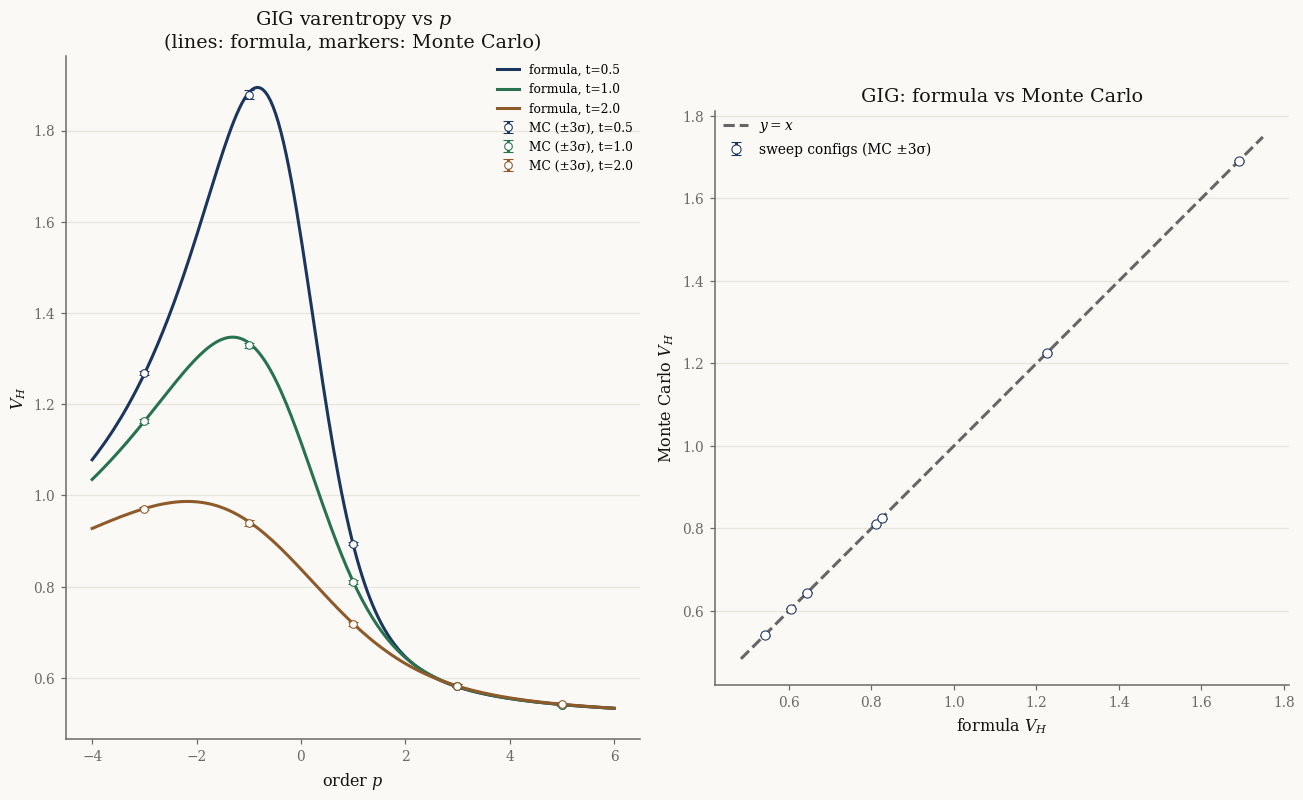

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: V_H(GIG) vs p, for several t = sqrt(ab) (set a = b = t), formula + MC points.
p_grid = np.linspace(-4.0, 6.0, 200)
p_pts = np.array([-3.0, -1.0, 1.0, 3.0, 5.0])
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, t in enumerate([0.5, 1.0, 2.0]):
    curve = [gig_varentropy_operator(p, t, t, hessian_ad) for p in p_grid]
    axes[0].plot(p_grid, curve, color=colors[i], lw=2, label=f"formula, t={t}")
    mc_vals, mc_err = zip(*[gig_varentropy_mc(p, t, t, n_per=400_000, n_seeds=10)
                            for p in p_pts])
    axes[0].errorbar(p_pts, mc_vals, yerr=np.array(mc_err) * 3, fmt="o", color=colors[i],
                     ms=5, capsize=3, mfc="white", label=f"MC (±3σ), t={t}")
axes[0].set(xlabel="order $p$", ylabel="$V_H$",
            title="GIG varentropy vs $p$\n(lines: formula, markers: Monte Carlo)")
axes[0].legend(fontsize=8, ncol=1)

# Right: agreement scatter across the full parameter sweep.
form = gig_table["operator(AD)"].to_numpy()
mc = gig_table["Monte Carlo"].to_numpy()
se = gig_table["MC ±SE"].to_numpy()
axes[1].errorbar(form, mc, yerr=se * 3, fmt="o", ms=6, capsize=3,
                 color=colors[0], mfc="white", label="sweep configs (MC ±3σ)")
lo, hi = min(form.min(), mc.min()), max(form.max(), mc.max())
pad = 0.05 * (hi - lo)
axes[1].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", label="$y=x$")
axes[1].set(xlabel="formula $V_H$", ylabel="Monte Carlo $V_H$",
            title="GIG: formula vs Monte Carlo", aspect="equal")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Joint GH varentropy: formula vs Monte Carlo

Now the joint mixture $f(x,y)=f(x\mid y)\,g(y)$ with $Y\sim\mathrm{GIG}(p,a,b)$ and
$X\mid Y=y\sim\mathcal N_d(\mu+\gamma y,\,\Sigma y)$. We compare the formula
$\tfrac d2+(L_d^2-L_d)\log K_p(t)$ against Monte Carlo of $-\log f(X,Y)$.

For the Monte Carlo we sample $(X,Y)$ with `normix`'s `JointGeneralizedHyperbolic.rvs`
and evaluate the joint surprisal with a from-scratch vectorized density; the next cell
confirms this from-scratch density agrees with `normix`'s `log_prob_joint` to machine
precision, so it is a faithful (and fast) stand-in.

In [6]:
def joint_neg_logpdf(X, Y, mu, gamma, Sigma, p, a, b):
    """-log f(x, y) = -log g(y) - log N(x; mu + gamma y, Sigma y), vectorized numpy."""
    d = len(mu)
    _, logdet = np.linalg.slogdet(Sigma)
    Sinv = np.linalg.inv(Sigma)
    R = X - mu[None, :] - gamma[None, :] * Y[:, None]
    quad = np.einsum("ni,ij,nj->n", R, Sinv, R) / Y             # (x-μ-γy)ᵀΣ⁻¹(x-μ-γy)/y
    neg_log_cond = (0.5 * d * np.log(2 * np.pi) + 0.5 * logdet
                    + 0.5 * d * np.log(Y) + 0.5 * quad)
    return gig_neg_logpdf(Y, p, a, b) + neg_log_cond


# Confirm the from-scratch joint surprisal matches normix.log_prob_joint.
_mu, _gamma = jnp.array([0.5, -1.0]), jnp.array([0.3, 0.7])
_Sigma = jnp.array([[2.0, 0.5], [0.5, 1.0]])
_model = JointGeneralizedHyperbolic.from_classical(
    mu=_mu, gamma=_gamma, sigma=_Sigma, p=-0.5, a=2.0, b=3.0)
_X, _Y = _model.rvs(2000, seed=1)
_normix = np.asarray(-jax.vmap(_model.log_prob_joint)(_X, _Y))
_scratch = joint_neg_logpdf(np.asarray(_X), np.asarray(_Y), np.asarray(_mu),
                            np.asarray(_gamma), np.asarray(_Sigma), -0.5, 2.0, 3.0)
print(f"max |from-scratch −log f  −  normix log_prob_joint| = "
      f"{np.max(np.abs(_normix - _scratch)):.2e}")

max |from-scratch −log f  −  normix log_prob_joint| = 6.22e-15


In [7]:
def joint_gh_varentropy_formula(p, a, b, d, hess=hessian_ad):
    t = float(np.sqrt(a * b))
    return d / 2.0 + operator_quadform(p, t, p - 1.0 - d / 2.0, hess)


def joint_gh_varentropy_fisher(p, a, b, d, backend="cpu"):
    g = GIG(p=p, a=a, b=b)
    I = np.asarray(g.fisher_information(backend=backend))
    theta_d = np.array([p - 1.0 - d / 2.0, -b / 2.0, -a / 2.0])
    return d / 2.0 + float(theta_d @ I @ theta_d)


def joint_gh_varentropy_mc(mu, gamma, Sigma, p, a, b, n_per=400_000, n_seeds=8):
    mu, gamma, Sigma = map(lambda v: np.asarray(v, float), (mu, gamma, Sigma))
    model = JointGeneralizedHyperbolic.from_classical(
        mu=jnp.asarray(mu), gamma=jnp.asarray(gamma), sigma=jnp.asarray(Sigma),
        p=p, a=a, b=b)
    ests = []
    for s in range(n_seeds):
        X, Y = model.rvs(n_per, seed=s)
        vals = joint_neg_logpdf(np.asarray(X), np.asarray(Y), mu, gamma, Sigma, p, a, b)
        ests.append(np.var(vals))
    ests = np.array(ests)
    return ests.mean(), ests.std(ddof=1) / np.sqrt(n_seeds)


# --- single worked example (d = 2) -----------------------------------------
mu, gamma = [0.5, -1.0], [0.3, 0.7]
Sigma = [[2.0, 0.5], [0.5, 1.0]]
p, a, b, d = -0.5, 2.0, 3.0, 2
mc, se = joint_gh_varentropy_mc(mu, gamma, Sigma, p, a, b)
print(f"Joint GH: d={d}, GIG(p={p}, a={a}, b={b}), Gaussian baseline d/2 = {d/2}\n")
print(f"  formula (AD)      : {joint_gh_varentropy_formula(p, a, b, d, hessian_ad):.6f}")
print(f"  formula (scipy)   : {joint_gh_varentropy_formula(p, a, b, d, hessian_scipy):.6f}")
print(f"  Fisher (cpu)      : {joint_gh_varentropy_fisher(p, a, b, d, 'cpu'):.6f}")
print(f"  Monte Carlo       : {mc:.6f}  ± {se:.6f}")

Joint GH: d=2, GIG(p=-0.5, a=2.0, b=3.0), Gaussian baseline d/2 = 1.0

  formula (AD)      : 2.902420
  formula (scipy)   : 2.902408
  Fisher (cpu)      : 2.902408
  Monte Carlo       : 2.900115  ± 0.003041


In [8]:
joint_configs = [
    dict(p=1.0, a=1.0, b=1.0, mu=[0.3], gamma=[-0.5], Sigma=[[2.0]]),
    dict(p=-0.5, a=2.0, b=3.0, mu=[0.0, 1.0], gamma=[0.5, -0.3],
         Sigma=[[1.5, 0.4], [0.4, 0.8]]),
    dict(p=2.0, a=1.5, b=0.7, mu=[1.0, -1.0, 0.5], gamma=[0.2, 0.1, -0.4],
         Sigma=[[2.0, 0.3, -0.2], [0.3, 1.0, 0.1], [-0.2, 0.1, 1.5]]),
    dict(p=-3.0, a=1.0, b=0.5, mu=[0.0] * 4, gamma=[0.4, -0.2, 0.1, 0.3],
         Sigma=np.diag([1.0, 2.0, 0.5, 1.5]).tolist()),
]

rows = []
for cfg in joint_configs:
    d = len(cfg["mu"])
    p, a, b = cfg["p"], cfg["a"], cfg["b"]
    mc, se = joint_gh_varentropy_mc(cfg["mu"], cfg["gamma"], cfg["Sigma"], p, a, b)
    f_ad = joint_gh_varentropy_formula(p, a, b, d, hessian_ad)
    rows.append({
        "d": d, "p": p, "a": a, "b": b, "d/2 baseline": d / 2.0,
        "formula(AD)": f_ad,
        "formula(scipy)": joint_gh_varentropy_formula(p, a, b, d, hessian_scipy),
        "Fisher(cpu)": joint_gh_varentropy_fisher(p, a, b, d, "cpu"),
        "Monte Carlo": mc, "MC ±SE": se,
        "|AD−MC|/SE": abs(f_ad - mc) / se,
    })

joint_table = pd.DataFrame(rows)
joint_table

,d,p,a,b,d/2 baseline,formula(AD),formula(scipy),Fisher(cpu),Monte Carlo,MC ±SE,|AD−MC|/SE
0,1,1.000000,1.000000,1.000000,0.500000,1.982357,1.982357,1.982357,1.986106,0.003335,1.124187
1,2,-0.500000,2.000000,3.000000,1.000000,2.902420,2.902408,2.902408,2.900115,0.003041,0.758173
2,3,2.000000,1.500000,0.700000,1.500000,4.148920,4.148920,4.148920,4.155086,0.004945,1.246886
3,4,-3.000000,1.000000,0.500000,2.000000,6.826658,6.826605,6.826603,6.828770,0.007043,0.299886


### 4.1 Independence from $\mu,\gamma,\Sigma$

The formula predicts that at fixed $d$ and fixed subordinator $(p,a,b)$, the joint
varentropy does **not** depend on $\mu$, $\gamma$, or $\Sigma$. We fix $d=2$,
$(p,a,b)=(-0.5,2,3)$ and vary the Gaussian block widely.

In [9]:
p, a, b, d = -0.5, 2.0, 3.0, 2
formula_val = joint_gh_varentropy_formula(p, a, b, d)

gaussian_variants = [
    dict(mu=[0.0, 0.0], gamma=[0.0, 0.0], Sigma=[[1.0, 0.0], [0.0, 1.0]]),
    dict(mu=[5.0, -3.0], gamma=[2.0, 1.0], Sigma=[[4.0, 1.5], [1.5, 2.0]]),
    dict(mu=[-2.0, 10.0], gamma=[-4.0, 3.0], Sigma=[[10.0, -2.0], [-2.0, 5.0]]),
]

rows = [{"formula": formula_val, "μ": "—", "γ": "—", "Monte Carlo": np.nan, "MC ±SE": np.nan}]
for v in gaussian_variants:
    mc, se = joint_gh_varentropy_mc(v["mu"], v["gamma"], v["Sigma"], p, a, b)
    rows.append({"formula": formula_val, "μ": str(v["mu"]), "γ": str(v["gamma"]),
                 "Monte Carlo": mc, "MC ±SE": se})

print("Joint varentropy at fixed d=2, GIG(-0.5, 2, 3), varying (μ, γ, Σ):")
pd.DataFrame(rows)

Joint varentropy at fixed d=2, GIG(-0.5, 2, 3), varying (μ, γ, Σ):


,formula,μ,γ,Monte Carlo,MC ±SE
0,2.902420,—,—,NaN,NaN
1,2.902420,"[0.0, 0.0]","[0.0, 0.0]",2.900115,0.003041
2,2.902420,"[5.0, -3.0]","[2.0, 1.0]",2.900115,0.003041
3,2.902420,"[-2.0, 10.0]","[-4.0, 3.0]",2.900115,0.003041


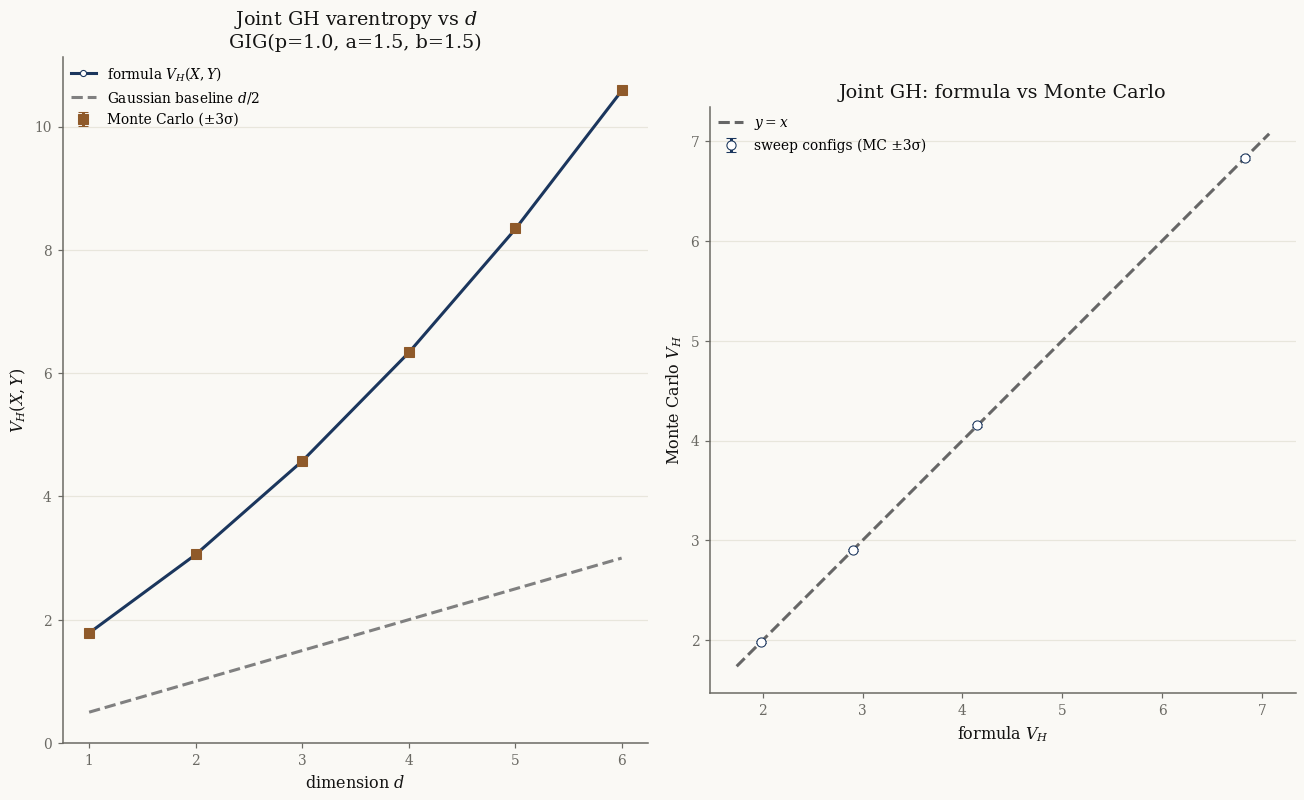

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: joint V_H vs dimension d, fixed GIG(p, a, b). μ, γ, Σ irrelevant, use identity block.
p, a, b = 1.0, 1.5, 1.5
d_vals = np.arange(1, 7)
form_curve, mc_vals, mc_err = [], [], []
for d in d_vals:
    form_curve.append(joint_gh_varentropy_formula(p, a, b, int(d)))
    mc, se = joint_gh_varentropy_mc(np.zeros(d), 0.3 * np.ones(d), np.eye(d), p, a, b,
                                    n_per=300_000, n_seeds=6)
    mc_vals.append(mc); mc_err.append(se)
axes[0].plot(d_vals, form_curve, "-o", color=colors[0], lw=2, mfc="white",
             label="formula $V_H(X,Y)$")
axes[0].errorbar(d_vals, mc_vals, yerr=np.array(mc_err) * 3, fmt="s", color=colors[2],
                 ms=6, capsize=3, label="Monte Carlo (±3σ)")
axes[0].plot(d_vals, d_vals / 2.0, "--", color="0.5", label="Gaussian baseline $d/2$")
axes[0].set(xlabel="dimension $d$", ylabel="$V_H(X,Y)$",
            title=f"Joint GH varentropy vs $d$\nGIG(p={p}, a={a}, b={b})")
axes[0].legend(fontsize=9)

# Right: agreement scatter across the joint sweep.
form = joint_table["formula(AD)"].to_numpy()
mc = joint_table["Monte Carlo"].to_numpy()
se = joint_table["MC ±SE"].to_numpy()
axes[1].errorbar(form, mc, yerr=se * 3, fmt="o", ms=6, capsize=3,
                 color=colors[0], mfc="white", label="sweep configs (MC ±3σ)")
lo, hi = min(form.min(), mc.min()), max(form.max(), mc.max())
pad = 0.05 * (hi - lo)
axes[1].plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", label="$y=x$")
axes[1].set(xlabel="formula $V_H$", ylabel="Monte Carlo $V_H$",
            title="Joint GH: formula vs Monte Carlo", aspect="equal")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Caveat: don't use `fisher_information(backend='jax')` for varentropy

All routes above agree with Monte Carlo **except** `Fisher(jax)`, which is off by a few
percent in the sweep. The reason is not the formula — it is how `normix` computes the
GIG Fisher matrix on the JAX path. Its analytical Hessian (`_hessian_log_partition`)
uses an *integer-shift finite difference* for the mixed order–argument derivative
$\partial_\nu\partial_z\log K_\nu$. That approximation is perfectly adequate for the
Newton solver (it only sets a step direction, and the solver damps the Hessian), but it
puts a coarse error into the off-diagonal entries $H_{12}, H_{13}$. In the varentropy
quadratic form $\theta_G^\top I_G\theta_G$ those entries are multiplied by
$\theta_1=p-1$, so the error is amplified when $|p|$ is large.

The cell below isolates this: `log_kv` itself and the diagonal Hessian entries are
machine-accurate; only the mixed $H_{12},H_{13}$ differ between the `jax` and `cpu`
backends, and that difference fully explains the `Fisher(jax)` gap.

In [11]:
rows = []
for p, a, b in [(5.0, 2.0, 2.0), (2.5, 0.5, 4.0), (-3.0, 1.0, 0.5)]:
    g = GIG(p=p, a=a, b=b)
    Hj = np.asarray(g.fisher_information("jax"))
    Hc = np.asarray(g.fisher_information("cpu"))
    dH = Hj - Hc
    rows.append({
        "(p,a,b)": str((p, a, b)),
        "max |ΔH_diag|": np.max(np.abs(np.diag(dH))),
        "|ΔH_12|": abs(dH[0, 1]), "|ΔH_13|": abs(dH[0, 2]),
        "VH Fisher(jax)": gig_varentropy_fisher(p, a, b, "jax"),
        "VH Fisher(cpu)": gig_varentropy_fisher(p, a, b, "cpu"),
        "VH operator(AD)": gig_varentropy_operator(p, a, b),
    })
print("Diagonal Hessian entries agree; off-diagonal mixed entries (ΔH_12, ΔH_13) do not:")
pd.DataFrame(rows)

Diagonal Hessian entries agree; off-diagonal mixed entries (ΔH_12, ΔH_13) do not:


,"(p,a,b)",max |ΔH_diag|,|ΔH_12|,|ΔH_13|,VH Fisher(jax),VH Fisher(cpu),VH operator(AD)
0,"(5.0, 2.0, 2.0)",0.000000,0.001777,0.001777,0.570299,0.541863,0.541898
1,"(2.5, 0.5, 4.0)",0.000003,0.004365,0.034921,0.657307,0.604930,0.604929
2,"(-3.0, 1.0, 0.5)",0.000004,0.017119,0.008559,1.293993,1.225495,1.225519


## 6. Tail-heaviness: varentropy vs kurtosis (research)

The GIG varentropy curve above is shaped by the order $p$, which controls the tail.
Nassim Taleb has argued that **varentropy** is a more robust fat-tailedness diagnostic
than **kurtosis**, because kurtosis needs a finite fourth moment whereas
$\operatorname{Var}[-\log f]$ does not. The GIG is a clean testbed for that claim.

*Tail behavior* (see `docs/theory/gig.rst`). For $a,b>0$ the GIG density behaves like
$f(x)\sim C\,x^{p-1}e^{-ax/2}$ as $x\to\infty$ and $C\,x^{p-1}e^{-b/(2x)}$ as $x\to0^+$:
an **exponential (semi-heavy) right tail** and a super-exponentially thin left tail, so
**all moments are finite** and the kurtosis exists. Genuine power-law heaviness appears
only at the boundary $a\to0$ (with $p<0$), where $f(x)\sim C\,x^{p-1}$ — the
**inverse-gamma limit** $\mathrm{InvGamma}(-p, b/2)$ with tail index $\alpha=-p$.

Both moments and varentropy are available in closed form, so we can compare them
directly as functions of $p$.

In [12]:
from scipy.special import polygamma


def gig_raw_moment(k, p, a, b):
    """E[X^k] = (b/a)^{k/2} K_{p+k}(t)/K_p(t),  t = sqrt(ab)  (closed form)."""
    t = np.sqrt(a * b)
    return (b / a) ** (k / 2.0) * np.exp(_logK_scipy(p + k, t) - _logK_scipy(p, t))


def gig_skewness_excess_kurtosis(p, a, b):
    """Skewness γ₁ and excess kurtosis γ₂ from the Bessel raw moments."""
    m1, m2, m3, m4 = (gig_raw_moment(k, p, a, b) for k in (1, 2, 3, 4))
    var = m2 - m1**2
    mu3 = m3 - 3 * m1 * m2 + 2 * m1**3
    mu4 = m4 - 4 * m1 * m3 + 6 * m1**2 * m2 - 3 * m1**4
    return mu3 / var**1.5, mu4 / var**2 - 3.0


def gig_excess_kurtosis(p, a, b):
    return gig_skewness_excess_kurtosis(p, a, b)[1]


# Verify the closed form against scipy and a Monte Carlo estimate.
rows = []
for p, a, b in [(1.0, 1.0, 1.0), (-0.5, 2.0, 3.0), (2.0, 1.5, 0.7), (-6.0, 1e-3, 1.0)]:
    sk_bes, ek_bes = gig_skewness_excess_kurtosis(p, a, b)
    b_sp, scale = np.sqrt(a * b), np.sqrt(b / a)
    sk_sp, ek_sp = stats.geninvgauss.stats(p=p, b=b_sp, scale=scale, moments="sk")
    Y = stats.geninvgauss.rvs(p=p, b=b_sp, scale=scale, size=5_000_000, random_state=0)
    rows.append({
        "p": p, "a": a, "b": b,
        "skew (Bessel)": sk_bes, "skew (scipy)": float(sk_sp),
        "exkurt (Bessel)": ek_bes, "exkurt (scipy)": float(ek_sp),
        "exkurt (MC)": stats.kurtosis(Y, fisher=True),
    })
pd.DataFrame(rows)

,p,a,b,skew (Bessel),skew (scipy),exkurt (Bessel),exkurt (scipy),exkurt (MC)
0,1.000000,1.000000,1.000000,1.804319,1.804319,4.997388,4.997388,5.004879
1,-0.500000,2.000000,3.000000,1.916829,1.916829,6.123724,6.123724,6.100522
2,2.000000,1.500000,0.700000,1.389091,1.389091,2.914403,2.914403,2.941659
3,-6.000000,0.001000,1.000000,2.666458,2.666458,18.993352,18.993352,18.934929


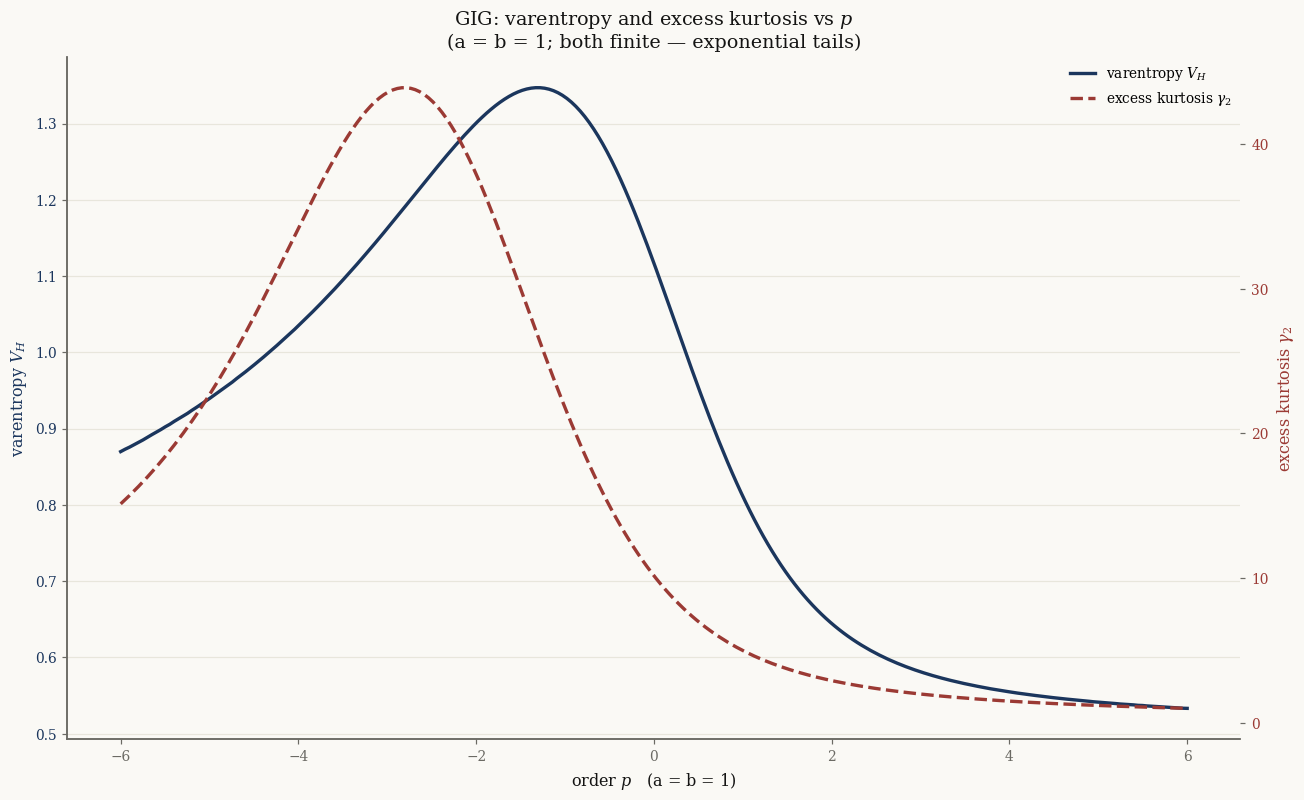

In [13]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Genuine GIG (a = b = 1, t = 1): exponential tails, so kurtosis is finite everywhere.
p_grid = np.linspace(-6.0, 6.0, 240)
vh_curve = np.array([gig_varentropy_operator(p, 1.0, 1.0) for p in p_grid])
ek_curve = np.array([gig_excess_kurtosis(p, 1.0, 1.0) for p in p_grid])

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
ax2 = ax1.twinx()
ax2.grid(False)
lv, = ax1.plot(p_grid, vh_curve, color=colors[0], lw=2.2, label="varentropy $V_H$")
lk, = ax2.plot(p_grid, ek_curve, color=colors[5], lw=2.2, ls="--",
               label="excess kurtosis $\\gamma_2$")
ax1.set_xlabel("order $p$   (a = b = 1)")
ax1.set_ylabel("varentropy $V_H$", color=colors[0])
ax2.set_ylabel("excess kurtosis $\\gamma_2$", color=colors[5])
ax1.tick_params(axis="y", labelcolor=colors[0])
ax2.tick_params(axis="y", labelcolor=colors[5])
ax1.set_title("GIG: varentropy and excess kurtosis vs $p$\n"
              "(a = b = 1; both finite — exponential tails)")
ax1.legend(handles=[lv, lk], loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.1 The heavy-tail limit — where kurtosis breaks and varentropy does not

Now push toward the inverse-gamma limit ($a\to0$, $p<0$), where the right tail becomes a
power law with index $\alpha=-p$. Standard InvGamma moment conditions give:

| quantity | exists iff | boundary |
|---|---|---|
| mean | $\alpha>1$ | $p=-1$ |
| variance | $\alpha>2$ | $p=-2$ |
| **kurtosis** ($E[X^4]$) | $\alpha>4$ | $p=-4$ |

So the excess kurtosis $\gamma_2=\dfrac{6(5\alpha-11)}{(\alpha-3)(\alpha-4)}$ diverges as
$\alpha\to4^+$ and is **undefined for $\alpha\le4$** (i.e. $-4\le p<0$).

The varentropy, by contrast, is $\theta_G^\top I_G\theta_G$ with $\theta_{G,3}=-a/2\to0$,
so in the limit only $[\log Y,\,1/Y]$ contribute. Both $\operatorname{Var}(\log Y)$ and
$\operatorname{Var}(1/Y)$ are finite for **every** $\alpha>0$ (indeed $1/Y$ is Gamma, with
all moments finite), giving the closed form

$$
V_H\{\mathrm{InvGamma}(\alpha=-p)\} = (p-1)^2\,\psi'(-p) + p - 2 ,
$$

which is finite and smooth across $p=-4$, $p=-2$, even $p=-1$ — it only diverges in the
degenerate $\alpha\to0$ limit. Varentropy stays a well-defined tail measure long after
kurtosis has ceased to exist.

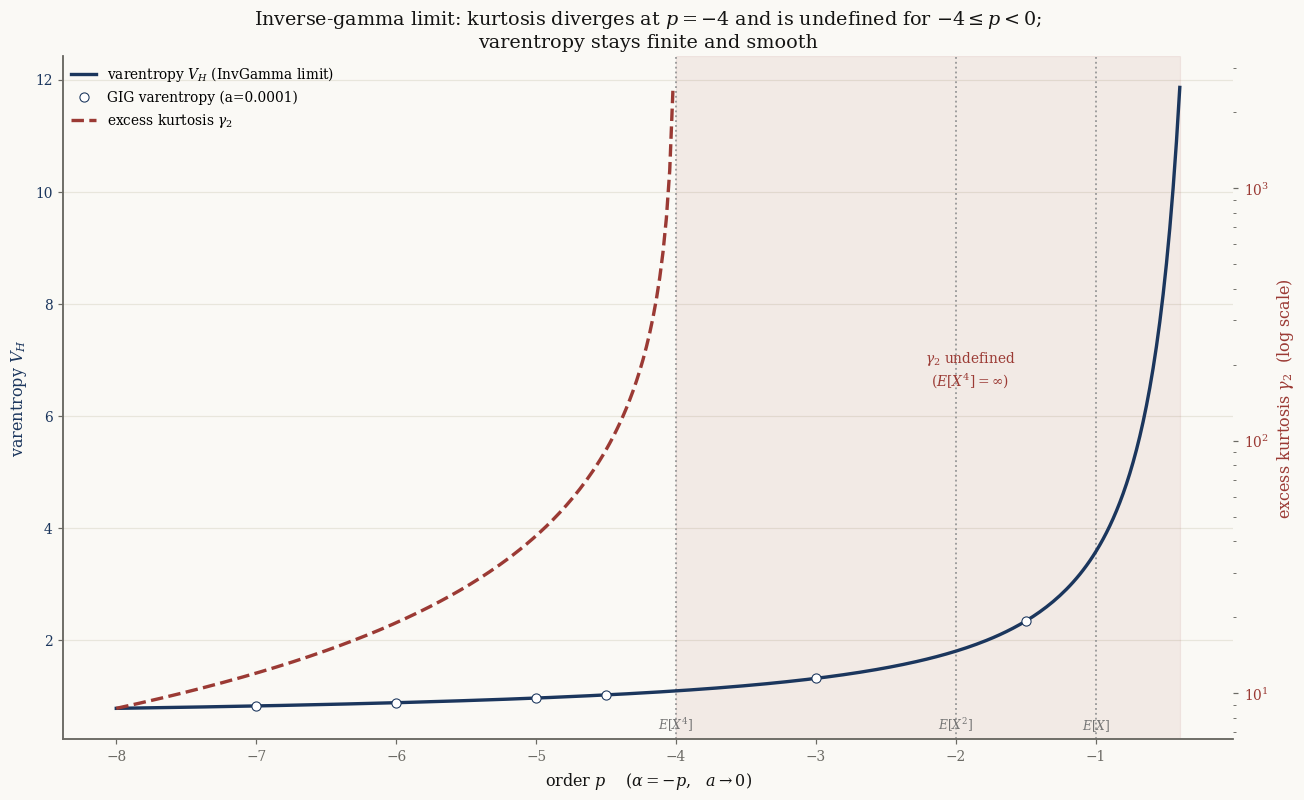

In [14]:
p_neg = np.linspace(-8.0, -0.4, 320)
alpha = -p_neg

# Exact inverse-gamma-limit curves.
vh_ig = (p_neg - 1.0) ** 2 * polygamma(1, -p_neg) + p_neg - 2.0
ek_ig = np.where(alpha > 4.0,
                 6.0 * (5.0 * alpha - 11.0) / ((alpha - 3.0) * (alpha - 4.0)), np.nan)

# GIG with small a, approaching the limit (varentropy markers).
a_small, b0 = 1e-4, 1.0
p_mark = np.array([-7.0, -6.0, -5.0, -4.5, -3.0, -1.5])
vh_gig_mark = np.array([gig_varentropy_operator(p, a_small, b0, hessian_scipy)
                        for p in p_mark])

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
ax2 = ax1.twinx()
ax2.grid(False)

# Shade α ≤ 4 (p ≥ −4): 4th moment, hence kurtosis, does not exist.
ax1.axvspan(-4.0, p_neg.max(), color=colors[5], alpha=0.08)
for pb, lbl in [(-4.0, "$E[X^4]$"), (-2.0, "$E[X^2]$"), (-1.0, "$E[X]$")]:
    ax1.axvline(pb, color="0.6", ls=":", lw=1.2)
    ax1.annotate(lbl, xy=(pb, 0.0), xycoords=("data", "axes fraction"),
                 xytext=(0, 4), textcoords="offset points",
                 ha="center", va="bottom", fontsize=8, color="0.45")

lv, = ax1.plot(p_neg, vh_ig, color=colors[0], lw=2.2,
               label="varentropy $V_H$ (InvGamma limit)")
mk, = ax1.plot(p_mark, vh_gig_mark, "o", color=colors[0], mfc="white", ms=6,
               label=f"GIG varentropy (a={a_small:g})")
lk, = ax2.plot(p_neg, ek_ig, color=colors[5], lw=2.2, ls="--",
               label="excess kurtosis $\\gamma_2$")
ax2.set_yscale("log")

ax1.set_xlabel("order $p$    ($\\alpha=-p$,   $a\\to 0$)")
ax1.set_ylabel("varentropy $V_H$", color=colors[0])
ax2.set_ylabel("excess kurtosis $\\gamma_2$  (log scale)", color=colors[5])
ax1.tick_params(axis="y", labelcolor=colors[0])
ax2.tick_params(axis="y", labelcolor=colors[5])
ax1.set_title("Inverse-gamma limit: kurtosis diverges at $p=-4$ and is undefined for "
              "$-4\\leq p<0$;\nvarentropy stays finite and smooth")
ax1.text(-1.9, ax1.get_ylim()[1] * 0.55, "$\\gamma_2$ undefined\n($E[X^4]=\\infty$)",
         ha="center", va="center", fontsize=9, color=colors[5])
ax1.legend(handles=[lv, mk, lk], loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Summary

- **Both formulas are numerically correct.** Across every parameter set tested, the
  GIG formula $V_H=(L^2-L)\log K_p(t)$ and the joint GH formula
  $V_H(X,Y)=\tfrac d2+(L_d^2-L_d)\log K_p(t)$ match Monte Carlo to within the Monte
  Carlo standard error (typically well under $3\sigma$).

- **The three analytic routes are consistent.** The autodiff Bessel operator, the
  independent scipy finite-difference operator, and the `cpu` Fisher form
  $\theta^\top I\theta$ all agree, confirming the algebraic identity
  $(L^2-L)\log K_p(t)=\theta_G^\top I_G\theta_G$ (and its shifted joint analogue).

- **Joint varentropy is invariant to $\mu,\gamma,\Sigma$** at fixed $d$ and $(p,a,b)$,
  exactly as the $\chi_d^2$ decomposition predicts — the Monte Carlo values are
  identical across the Gaussian variants.

- **Implementation guidance (for a future `varentropy()`).** Prefer the Bessel operator
  via `jax.grad` on `log_kv` (accurate, JIT-able, differentiable), or `θᵀIθ` with
  `fisher_information(backend='cpu')`. **Avoid** `fisher_information(backend='jax')`: its
  analytical Hessian uses a coarse integer-shift FD for the mixed
  $\partial_\nu\partial_z$ term that is fine for the Newton solver but injects a
  several-percent error into the varentropy quadratic form.

- **Varentropy vs kurtosis (§6).** GIG kurtosis has a closed form via Bessel moments and
  matches scipy/Monte Carlo. For $a,b>0$ (exponential tails) both kurtosis and varentropy
  are finite and track $p$. But in the heavy-tailed inverse-gamma limit ($a\to0$), the
  kurtosis diverges at $p=-4$ and is **undefined for $-4\le p<0$**, whereas the varentropy
  $(p-1)^2\psi'(-p)+p-2$ stays finite and smooth — even past the mean/variance boundaries.
  This supports Taleb's view of varentropy as a fat-tailedness measure that does not
  require a finite fourth moment. GIG tail behavior is now documented in
  `docs/theory/gig.rst`.